# Machine Learning Course - Module 2: Supervised Learning Algorithms
## Linear Regression & Logistic Regression

Welcome to **Module 2** of the Supervised Machine Learning course! In this notebook, we will explore two fundamental algorithms in machine learning:
1. **Linear Regression**: A core algorithm for predicting continuous target variables.
2. **Logistic Regression**: A foundational algorithm for binary and multi-class classification problems.

---

### Notebook Outline
- **1. Linear Regression**
  - 1.1 Simple Linear Regression with `scikit-learn`
  - 1.2 Multiple Linear Regression & Evaluation Metrics (MAE, MSE, RMSE, $R^2$)
  - 1.3 Batch Gradient Descent from Scratch & Loss Surface Visualization
  - 1.4 $R^2$ vs Adjusted $R^2$ Analysis
  - 1.5 Residual Analysis & Diagnostic Plots
- **2. Logistic Regression**
  - 2.1 The Sigmoid Function & Odds Ratio
  - 2.2 Binary Classification with `scikit-learn`
  - 2.3 Confusion Matrix, Classification Report & ROC-AUC
  - 2.4 Decision Boundary Visualization
  - 2.5 Multi-Class Logistic Regression (One-vs-Rest & Softmax)
- **3. Summary & Comparison Table**

Let's start by importing the necessary libraries and setting plot styling options.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Scikit-learn datasets, models, and metrics
from sklearn.datasets import load_diabetes, load_breast_cancer, load_iris, make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay
)

# Plotting aesthetic configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("Libraries imported successfully!")


Libraries imported successfully!


# 1. Linear Regression

Linear Regression is a supervised learning algorithm used to model the relationship between a dependent target variable $y$ (continuous) and one or more independent explanatory features $X$.

### Mathematical Formulation
For a single feature $x$, the **Simple Linear Regression** model is expressed as:

$$y = \beta_0 + \beta_1 x + \epsilon$$

Where:
- $y$: Target variable (continuous outcome)
- $x$: Input feature
- $\beta_0$: Intercept (value of $y$ when $x = 0$)
- $\beta_1$: Slope / Coefficient (change in $y$ per unit change in $x$)
- $\epsilon$: Error term / residual (assumed $\epsilon \sim \mathcal{N}(0, \sigma^2)$)

The goal of Ordinary Least Squares (OLS) estimation is to find coefficients $\hat{\beta}_0$ and $\hat{\beta}_1$ that minimize the **Sum of Squared Errors (SSE)**:

$$\text{SSE} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \sum_{i=1}^{n} (y_i - (\beta_0 + \beta_1 x_i))^2$$


## 1.1 Simple Linear Regression with `scikit-learn`

Let's use the **Diabetes dataset** provided by `sklearn.datasets`. We will focus on predicting quantitative disease progression using a single feature: **Body Mass Index (BMI)**.


In [2]:
# Load diabetes dataset
diabetes = load_diabetes(as_frame=True)
df_diabetes = diabetes.frame

# Select a single feature (BMI) and target (Disease Progression)
X_simple = df_diabetes[['bmi']]
y_simple = df_diabetes['target']

# Split into train and test sets (80% train, 20% test)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

# Initialize and train Simple Linear Regression model
simple_lr = LinearRegression()
simple_lr.fit(X_train_s, y_train_s)

# Extract slope (beta_1) and intercept (beta_0)
beta_1 = simple_lr.coef_[0]
beta_0 = simple_lr.intercept_

print(f"Intercept (beta_0): {beta_0:.4f}")
print(f"Slope / BMI Coefficient (beta_1): {beta_1:.4f}")
print(f"Model Equation: y = {beta_0:.2f} + {beta_1:.2f} * BMI")


Intercept (beta_0): 152.0034
Slope / BMI Coefficient (beta_1): 998.5777
Model Equation: y = 152.00 + 998.58 * BMI


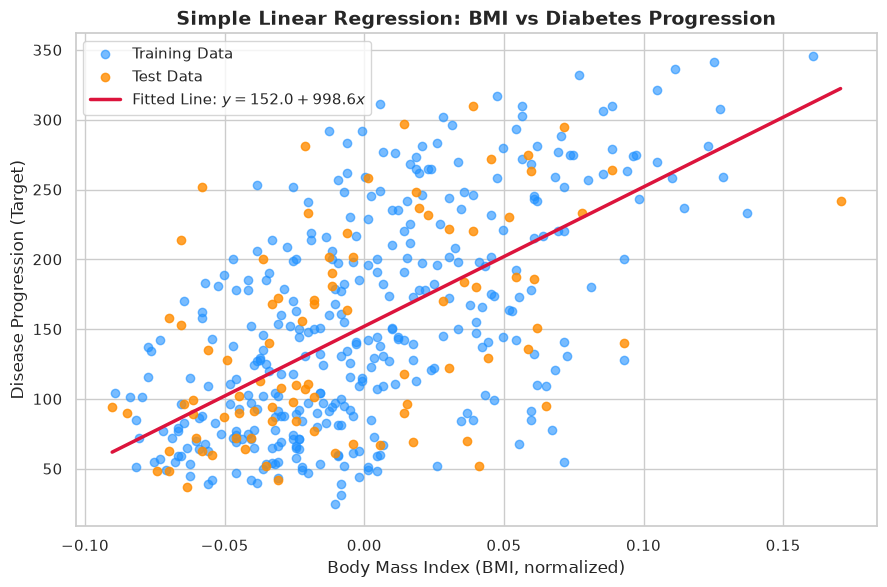

In [3]:
# Visualize Simple Linear Regression Fit
y_pred_s = simple_lr.predict(X_test_s)

plt.figure(figsize=(9, 6))
plt.scatter(X_train_s, y_train_s, color='dodgerblue', alpha=0.6, label='Training Data')
plt.scatter(X_test_s, y_test_s, color='darkorange', alpha=0.8, label='Test Data')

# Generate smooth line for regression
x_range = np.linspace(X_simple.min().values[0], X_simple.max().values[0], 100).reshape(-1, 1)
x_range_df = pd.DataFrame(x_range, columns=['bmi'])
y_range_pred = simple_lr.predict(x_range_df)
plt.plot(x_range, y_range_pred, color='crimson', linewidth=2.5, 
         label=f'Fitted Line: $y = {beta_0:.1f} + {beta_1:.1f}x$')

plt.title("Simple Linear Regression: BMI vs Diabetes Progression", fontsize=14, fontweight='bold')
plt.xlabel("Body Mass Index (BMI, normalized)", fontsize=12)
plt.ylabel("Disease Progression (Target)", fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()


## 1.2 Multiple Linear Regression

When we have $p$ features $x_1, x_2, \dots, x_p$, the model generalizes to **Multiple Linear Regression**:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p + \epsilon$$

In Matrix Notation:
$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\epsilon}$$

The closed-form OLS solution (Normal Equation) is given by:
$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

### Regression Evaluation Metrics
To measure model performance, we evaluate predicted values $\hat{y}_i$ against actual values $y_i$:

1. **Mean Absolute Error (MAE)**: Average magnitude of errors. Less sensitive to extreme outliers.
   $$\text{MAE} = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|$$

2. **Mean Squared Error (MSE)**: Average of squared errors. Penalizes larger errors heavily.
   $$\text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$$

3. **Root Mean Squared Error (RMSE)**: Square root of MSE. In the same units as the target variable $y$.
   $$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}$$

4. **Coefficient of Determination ($R^2$)**: Proportion of variance in $y$ explained by features.
   $$R^2 = 1 - \frac{\text{SS}_{res}}{\text{SS}_{tot}} = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$


In [4]:
# Load full diabetes dataset with all features
X_multi = df_diabetes.drop(columns=['target'])
y_multi = df_diabetes['target']

# Train / Test split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

# Standardize features for comparable coefficient weights
scaler_multi = StandardScaler()
X_train_m_scaled = scaler_multi.fit_transform(X_train_m)
X_test_m_scaled = scaler_multi.transform(X_test_m)

# Train Multiple Linear Regression model
multi_lr = LinearRegression()
multi_lr.fit(X_train_m_scaled, y_train_m)

# Make predictions on test set
y_pred_m = multi_lr.predict(X_test_m_scaled)

# Calculate performance metrics
mae = mean_absolute_error(y_test_m, y_pred_m)
mse = mean_squared_error(y_test_m, y_pred_m)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_m, y_pred_m)

print("--- Multiple Linear Regression Results ---")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R^2  : {r2:.4f}\n")

# Display feature coefficients table
coeff_df = pd.DataFrame({
    'Feature': X_multi.columns,
    'Coefficient (Scaled)': multi_lr.coef_
}).sort_values(by='Coefficient (Scaled)', key=abs, ascending=False)

print("Feature Coefficients (Sorted by magnitude):")
print(coeff_df.to_string(index=False))


--- Multiple Linear Regression Results ---
MAE  : 42.7941
MSE  : 2900.1936
RMSE : 53.8534
R^2  : 0.4526

Feature Coefficients (Sorted by magnitude):
Feature  Coefficient (Scaled)
     s1            -44.448856
     s5             35.161195
    bmi             25.607121
     s2             24.640954
     bp             16.828872
     s4             13.138784
    sex            -11.511809
     s3              7.676978
     s6              2.351364
    age              1.753758


## 1.3 Gradient Descent from Scratch

While OLS provides an exact matrix solution $\hat{\boldsymbol{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$, computing matrix inversion $(\mathbf{X}^T \mathbf{X})^{-1}$ becomes computationally prohibitive $O(p^3)$ when the feature dimension $p$ is very large.

**Gradient Descent** is an iterative optimization algorithm that finds model parameters $\boldsymbol{\theta} = [\theta_0, \theta_1]^T$ by stepping in the direction opposite to the gradient of the Mean Squared Error cost function $J(\boldsymbol{\theta})$:

$$J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2$$

Where the hypothesis is $h_\theta(x) = \theta_0 + \theta_1 x$.

### Gradient Update Rule
For each iteration, parameters are updated simultaneously:
$$\theta_0 := \theta_0 - \alpha \frac{\partial J}{\partial \theta_0} = \theta_0 - \alpha \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})$$

$$\theta_1 := \theta_1 - \alpha \frac{\partial J}{\partial \theta_1} = \theta_1 - \alpha \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) x^{(i)}$$

Where $\alpha$ is the **learning rate**.


In [5]:
# Generate synthetic 1D regression dataset for clear visualization
np.random.seed(42)
X_gd_raw = 2 * np.random.rand(100, 1)
y_gd = 4 + 3 * X_gd_raw + np.random.randn(100, 1)  # True intercept=4, slope=3

# Add bias column x0 = 1 to feature matrix X
X_gd = np.c_[np.ones((100, 1)), X_gd_raw]

def batch_gradient_descent(X, y, alpha=0.1, n_iterations=100):
    m = len(y)
    theta = np.random.randn(2, 1)  # Random initialization
    theta_history = [theta.copy()]
    cost_history = []
    
    for iteration in range(n_iterations):
        predictions = X.dot(theta)
        errors = predictions - y
        cost = (1 / (2 * m)) * np.sum(errors ** 2)
        cost_history.append(cost)
        
        gradients = (1 / m) * X.T.dot(errors)
        theta = theta - alpha * gradients
        theta_history.append(theta.copy())
        
    return theta, np.array(theta_history), cost_history

alpha = 0.1
n_iter = 100
final_theta, theta_history, cost_history = batch_gradient_descent(X_gd, y_gd, alpha=alpha, n_iterations=n_iter)

print(f"Gradient Descent Results after {n_iter} iterations (Learning Rate alpha = {alpha}):")
print(f"Estimated Intercept (theta_0): {final_theta[0][0]:.4f} (True: 4.0)")
print(f"Estimated Slope     (theta_1): {final_theta[1][0]:.4f} (True: 3.0)")


Gradient Descent Results after 100 iterations (Learning Rate alpha = 0.1):
Estimated Intercept (theta_0): 3.9067 (True: 4.0)
Estimated Slope     (theta_1): 3.0424 (True: 3.0)


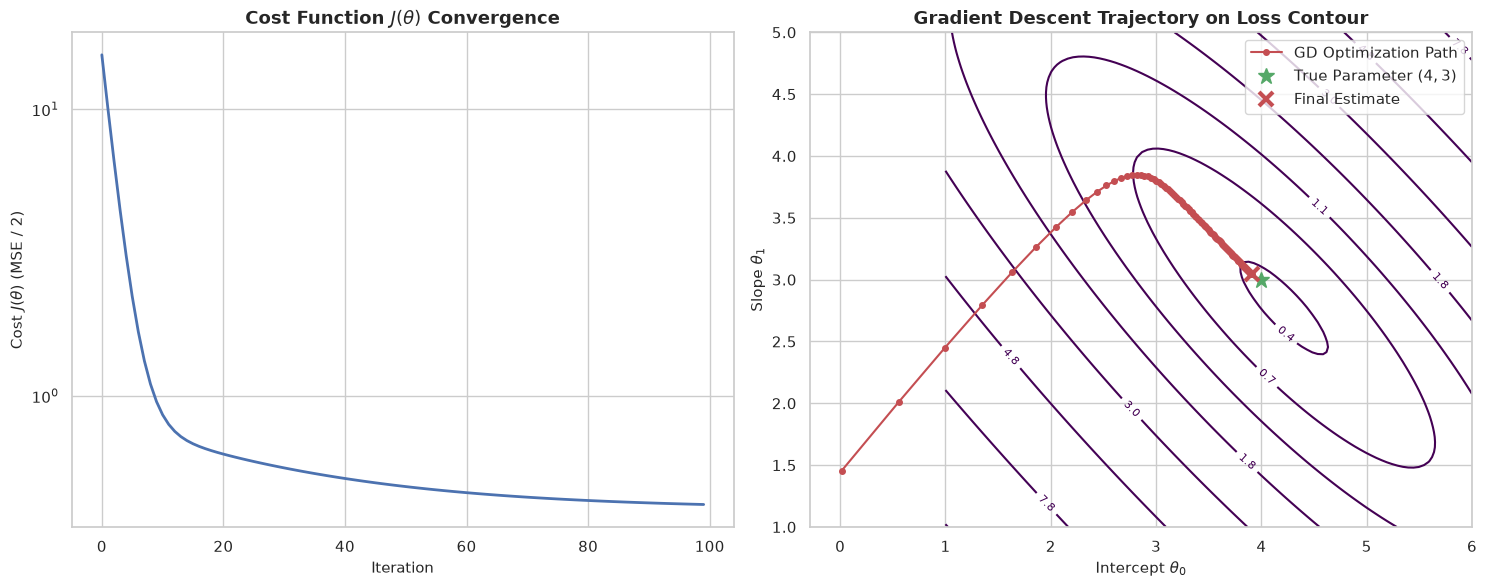

In [6]:
# Visualization: Cost Function Convergence & 2D Parameter Contour Map
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Loss Convergence Curve
axes[0].plot(range(len(cost_history)), cost_history, 'b-', linewidth=2)
axes[0].set_title("Cost Function $J(\\theta)$ Convergence", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Iteration", fontsize=11)
axes[0].set_ylabel("Cost $J(\\theta)$ (MSE / 2)", fontsize=11)
axes[0].set_yscale('log')

# Subplot 2: Contour Map of Cost Surface and Gradient Trajectory
theta0_vals = np.linspace(1, 6, 100)
theta1_vals = np.linspace(1, 5, 100)
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)
J_vals = np.zeros_like(T0)

m = len(y_gd)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        t = np.array([[T0[i, j]], [T1[i, j]]])
        J_vals[i, j] = (1 / (2 * m)) * np.sum((X_gd.dot(t) - y_gd) ** 2)

cp = axes[1].contour(T0, T1, J_vals, levels=np.logspace(-1, 3, 20), cmap='viridis')
axes[1].clabel(cp, inline=1, fontsize=8)

# Overlay parameter trajectory
th_hist = np.array(theta_history).squeeze()
axes[1].plot(th_hist[:, 0], th_hist[:, 1], 'r-o', markersize=4, linewidth=1.5, label='GD Optimization Path')
axes[1].plot(4.0, 3.0, 'g*', markersize=12, label='True Parameter $(4, 3)$')
axes[1].plot(final_theta[0][0], final_theta[1][0], 'rx', markersize=10, markeredgewidth=3, label='Final Estimate')

axes[1].set_title("Gradient Descent Trajectory on Loss Contour", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Intercept $\\theta_0$", fontsize=11)
axes[1].set_ylabel("Slope $\\theta_1$", fontsize=11)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()


## 1.4 $R^2$ and Adjusted $R^2$

The **Coefficient of Determination ($R^2$)** measures the fraction of total variance in $y$ explained by the features:

$$R^2 = 1 - \frac{\text{SS}_{res}}{\text{SS}_{tot}} = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2}$$

### Flaw of Standard $R^2$
Standard $R^2$ **monotonically increases (or stays constant)** whenever additional features are added to the model—even if those features are completely random noise with zero predictive value!

### Adjusted $R^2$ Solution
**Adjusted $R^2$** incorporates a penalty for the number of predictors $p$ relative to the sample size $n$:

$$R^2_{adj} = 1 - \left[ \frac{(1 - R^2)(n - 1)}{n - p - 1} \right]$$

Where:
- $n$: Total number of observations (sample size)
- $p$: Total number of explanatory features

If a new feature does not improve $R^2$ by more than expected by chance, $R^2_{adj}$ **decreases**.

Let's test this behavior experimentally by adding pure noise features step-by-step.


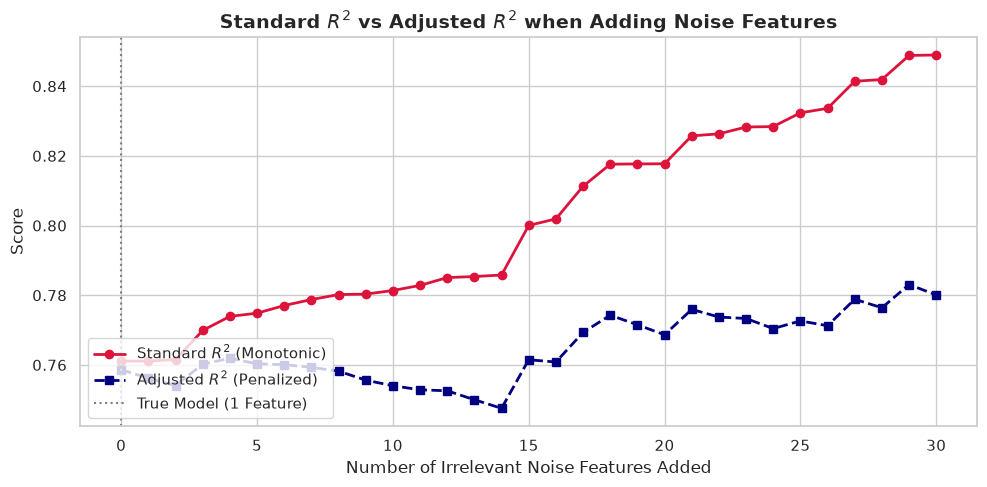

In [7]:
# Experiment: Adding pure noise features to observe R^2 vs Adjusted R^2 behavior
np.random.seed(42)
n_samples = 100

# Base signal: y is driven purely by x1
X_base = np.random.randn(n_samples, 1)
y_exp = 3 * X_base.ravel() + 2 + np.random.randn(n_samples) * 1.5

r2_list = []
adj_r2_list = []

num_noise_features = 30
X_current = X_base.copy()

for k in range(num_noise_features + 1):
    # Fit linear regression
    model = LinearRegression().fit(X_current, y_exp)
    y_pred = model.predict(X_current)
    
    n = n_samples
    p = X_current.shape[1]
    
    r2 = r2_score(y_exp, y_pred)
    adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
    
    r2_list.append(r2)
    adj_r2_list.append(adj_r2)
    
    # Add a new column of pure random Gaussian noise
    noise = np.random.randn(n_samples, 1)
    X_current = np.hstack([X_current, noise])

# Plotting R^2 vs Adjusted R^2
plt.figure(figsize=(10, 5))
plt.plot(range(num_noise_features + 1), r2_list, 'o-', color='crimson', linewidth=2, label='Standard $R^2$ (Monotonic)')
plt.plot(range(num_noise_features + 1), adj_r2_list, 's--', color='navy', linewidth=2, label='Adjusted $R^2$ (Penalized)')

plt.title("Standard $R^2$ vs Adjusted $R^2$ when Adding Noise Features", fontsize=14, fontweight='bold')
plt.xlabel("Number of Irrelevant Noise Features Added", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.axvline(x=0, color='gray', linestyle=':', label='True Model (1 Feature)')
plt.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()


## 1.5 Residual Analysis & Model Diagnostics

Residuals are the differences between observed actual values and predicted values:

$$e_i = y_i - \hat{y}_i$$

To validate whether OLS Linear Regression is an appropriate model, we check four classical statistical assumptions:
1. **Linearity**: The relationship between features and target is linear.
2. **Homoscedasticity**: The variance of errors $e_i$ is constant across fitted values $\hat{y}$.
3. **Independence**: Residuals are uncorrelated.
4. **Normality**: Residuals follow a normal distribution $\mathcal{N}(0, \sigma^2)$.

### Diagnostic Plots
1. **Residuals vs Fitted Values Plot**: Checks for non-linearity and heteroscedasticity (e.g. funnel shape).
2. **Residual Distribution Histogram + KDE**: Checks for skewness and zero mean.
3. **Q-Q Plot (Quantile-Quantile Plot)**: Compares residual quantiles against theoretical standard normal quantiles.


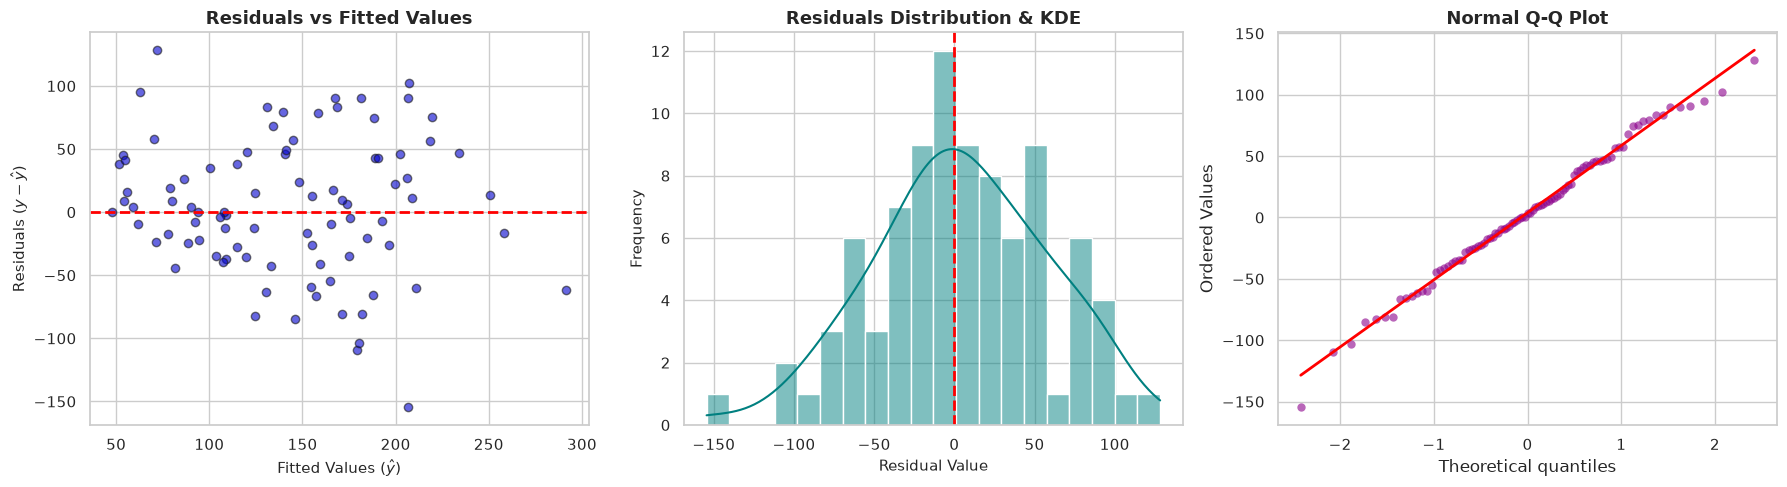

In [8]:
# Compute residuals from Multiple Linear Regression test set
residuals = y_test_m - y_pred_m

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Residuals vs Fitted Values (Homoscedasticity Check)
axes[0].scatter(y_pred_m, residuals, color='mediumblue', alpha=0.6, edgecolors='k')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title("Residuals vs Fitted Values", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Fitted Values ($\hat{y}$)", fontsize=11)
axes[0].set_ylabel("Residuals ($y - \hat{y}$)", fontsize=11)

# Plot 2: Distribution of Residuals (Normality Check)
sns.histplot(residuals, kde=True, ax=axes[1], color='teal', bins=20)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title("Residuals Distribution & KDE", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Residual Value", fontsize=11)
axes[1].set_ylabel("Frequency", fontsize=11)

# Plot 3: Q-Q Plot (Quantile-Quantile Plot)
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].get_lines()[0].set_markerfacecolor('darkmagenta')
axes[2].get_lines()[0].set_markeredgecolor('none')
axes[2].get_lines()[0].set_alpha(0.6)
axes[2].get_lines()[1].set_color('red')
axes[2].get_lines()[1].set_linewidth(2)
axes[2].set_title("Normal Q-Q Plot", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


# 2. Logistic Regression

Unlike Linear Regression (used for continuous regression), **Logistic Regression** is used for **classification** problems where the output variable $y$ is categorical (e.g., $y \in \{0, 1\}$).

---

## 2.1 The Sigmoid Function

Linear Regression produces unbounded outputs $z = \boldsymbol{w}^T \mathbf{x} + b \in (-\infty, \infty)$. To convert $z$ into a valid probability $p \in (0, 1)$, Logistic Regression passes $z$ through the **Sigmoid Activation Function** (also called the Logistic Function):

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Where $z = w_1 x_1 + w_2 x_2 + \dots + w_p x_p + b$.

### Key Mathematical Properties
1. **Output Range**: $\sigma(z) \in (0, 1)$ for all $z$.
2. **Symmetry**: $\sigma(0) = 0.5$, $\sigma(-z) = 1 - \sigma(z)$.
3. **Decision Rule**:
   - If $z \ge 0 \implies \sigma(z) \ge 0.5 \implies \hat{y} = 1$
   - If $z < 0 \implies \sigma(z) < 0.5 \implies \hat{y} = 0$

4. **Log-Odds (Logit)**:
   Taking the natural logarithm of odds $\frac{p}{1-p}$ reveals the underlying linear decision model:
   $$\ln\left(\frac{p}{1-p}\right) = \boldsymbol{w}^T \mathbf{x} + b$$


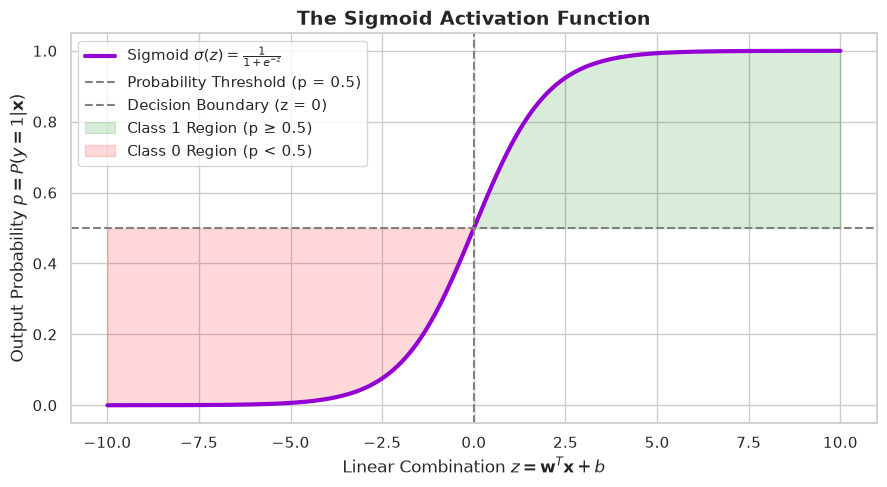

In [9]:
# Define Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_vals = np.linspace(-10, 10, 200)
p_vals = sigmoid(z_vals)

plt.figure(figsize=(9, 5))
plt.plot(z_vals, p_vals, color='darkviolet', linewidth=3, label=r'Sigmoid $\sigma(z) = \frac{1}{1 + e^{-z}}$')

# Annotating decision threshold
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5, label='Probability Threshold (p = 0.5)')
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1.5, label='Decision Boundary (z = 0)')

plt.fill_between(z_vals, p_vals, 0.5, where=(z_vals>=0), color='green', alpha=0.15, label='Class 1 Region (p ≥ 0.5)')
plt.fill_between(z_vals, p_vals, 0.5, where=(z_vals<0), color='red', alpha=0.15, label='Class 0 Region (p < 0.5)')

plt.title("The Sigmoid Activation Function", fontsize=14, fontweight='bold')
plt.xlabel(r"Linear Combination $z = \mathbf{w}^T \mathbf{x} + b$", fontsize=12)
plt.ylabel(r"Output Probability $p = P(y=1|\mathbf{x})$", fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()


## 2.2 Binary Classification with `scikit-learn`

### Loss Function: Binary Cross-Entropy (Log Loss)
In logistic regression, MSE is non-convex with sigmoid activation. Instead, we minimize **Binary Cross-Entropy Loss**:

$$J(\mathbf{w}, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \ln(\hat{y}^{(i)}) + (1 - y^{(i)}) \ln(1 - \hat{y}^{(i)}) \right]$$

Where $\hat{y}^{(i)} = \sigma(\mathbf{w}^T \mathbf{x}^{(i)} + b)$.

Let's train a Logistic Regression model on the **Breast Cancer Wisconsin Dataset** to classify tumors as **Malignant (0)** or **Benign (1)**.


In [10]:
# Load Breast Cancer dataset
cancer = load_breast_cancer(as_frame=True)
X_cancer = cancer.data
y_cancer = cancer.target  # 0: Malignant, 1: Benign

# Train/Test Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.25, random_state=42, stratify=y_cancer
)

# Standardize features
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

# Train Logistic Regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_c_scaled, y_train_c)

# Predict hard labels and soft probabilities
y_pred_c = log_reg.predict(X_test_c_scaled)
y_prob_c = log_reg.predict_proba(X_test_c_scaled)[:, 1]

# Inspect sample predictions
sample_df = pd.DataFrame({
    'Actual Label': y_test_c[:10].values,
    'Predicted Label': y_pred_c[:10],
    'Predicted Prob (Benign)': y_prob_c[:10].round(4)
})

print("Sample Predictions vs Actual Labels:")
print(sample_df.to_string(index=False))


Sample Predictions vs Actual Labels:
 Actual Label  Predicted Label  Predicted Prob (Benign)
            1                1                   0.9690
            0                0                   0.0004
            1                1                   0.5594
            1                1                   0.9389
            0                0                   0.1755
            0                0                   0.0000
            0                0                   0.0028
            0                0                   0.0008
            0                0                   0.0007
            1                1                   0.9999


## 2.3 Confusion Matrix & Classification Metrics

Evaluating classification models requires inspecting confusion matrix metrics beyond simple overall accuracy.

### Confusion Matrix Breakdown
| | Predicted Negative (0) | Predicted Positive (1) |
|---|---|---|
| **Actual Negative (0)** | **True Negative (TN)** | **False Positive (FP)** (Type I Error) |
| **Actual Positive (1)** | **False Negative (FN)** (Type II Error) | **True Positive (TP)** |

### Metric Equations
1. **Accuracy**: Overall fraction of correct predictions.
   $$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

2. **Precision**: Fraction of positive predictions that were actually positive.
   $$\text{Precision} = \frac{TP}{TP + FP}$$

3. **Recall (Sensitivity)**: Fraction of actual positive instances correctly identified.
   $$\text{Recall} = \frac{TP}{TP + FN}$$

4. **F1-Score**: Harmonic mean of Precision and Recall.
   $$\text{F1-Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

5. **ROC-AUC**: **Receiver Operating Characteristic - Area Under Curve** plots True Positive Rate vs False Positive Rate across all decision thresholds.


Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



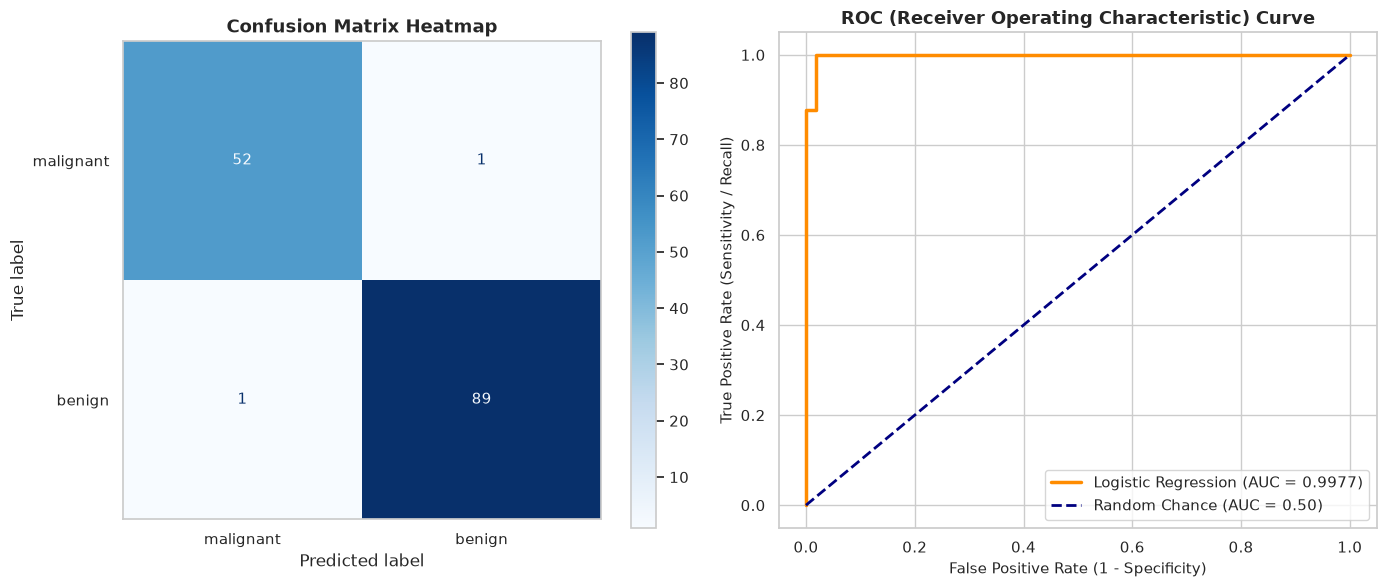

In [11]:
# Generate Confusion Matrix and Classification Report
cm = confusion_matrix(y_test_c, y_pred_c)
print("Classification Report:")
print(classification_report(y_test_c, y_pred_c, target_names=cancer.target_names))

# Compute ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_c, y_prob_c)
roc_auc = auc(fpr, tpr)

# Plotting Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Confusion Matrix Heatmap
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cancer.target_names)
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title("Confusion Matrix Heatmap", fontsize=13, fontweight='bold')
axes[0].grid(False)

# Plot 2: ROC Curve
axes[1].plot(fpr, tpr, color='darkorange', linewidth=2.5, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', linewidth=2, linestyle='--', label='Random Chance (AUC = 0.50)')
axes[1].set_title("ROC (Receiver Operating Characteristic) Curve", fontsize=13, fontweight='bold')
axes[1].set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
axes[1].set_ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=11)
axes[1].legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()


## 2.4 Decision Boundary Visualization

In 2D feature space $(x_1, x_2)$, the decision boundary is the line where the model is equally uncertain:

$$\sigma(w_1 x_1 + w_2 x_2 + b) = 0.5 \iff w_1 x_1 + w_2 x_2 + b = 0$$

Solving for $x_2$ yields the linear boundary equation:

$$x_2 = -\frac{w_1}{w_2} x_1 - \frac{b}{w_2}$$

Let's visualize this boundary on a 2D feature space selected from the dataset.


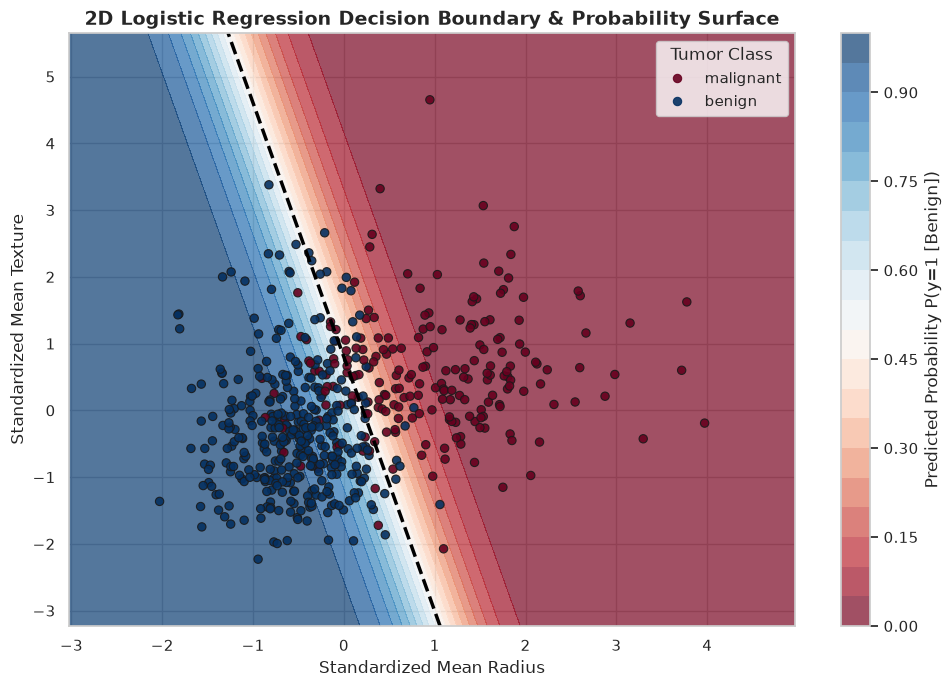

In [12]:
# Select 2 top features for 2D visualization: mean radius & mean texture
X_2d = cancer.data[['mean radius', 'mean texture']].values
y_2d = cancer.target.values

# Standardize 2D features
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

# Train Logistic Regression on 2D space
log_reg_2d = LogisticRegression(random_state=42)
log_reg_2d.fit(X_2d_scaled, y_2d)

# Create meshgrid for prediction probability contours
x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict probabilities over the grid
Z_prob = log_reg_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z_prob = Z_prob.reshape(xx.shape)

# Plotting Decision Boundary
plt.figure(figsize=(10, 7))

# Contour plot showing probability gradient
contour = plt.contourf(xx, yy, Z_prob, levels=20, cmap='RdBu', alpha=0.7)
plt.colorbar(contour, label='Predicted Probability P(y=1 [Benign])')

# Explicit Decision Boundary line (p = 0.5)
plt.contour(xx, yy, Z_prob, levels=[0.5], colors='black', linewidths=2.5, linestyles='--')

# Scatter actual data points
scatter = plt.scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1], c=y_2d, 
                      cmap='RdBu', edgecolors='k', linewidth=0.8, alpha=0.9)

plt.title("2D Logistic Regression Decision Boundary & Probability Surface", fontsize=14, fontweight='bold')
plt.xlabel("Standardized Mean Radius", fontsize=12)
plt.ylabel("Standardized Mean Texture", fontsize=12)

# Legend setup
handles, _ = scatter.legend_elements()
plt.legend(handles, cancer.target_names, loc='upper right', title="Tumor Class")
plt.tight_layout()
plt.show()


## 2.5 Multi-Class Logistic Regression

When predicting target categories across $K > 2$ classes (e.g. Iris species: Setosa, Versicolor, Virginica), Logistic Regression expands using one of two strategies:

### 1. One-vs-Rest (OvR / One-vs-All)
Trains $K$ separate binary classifiers. Classifier $k$ predicts $P(y=k \text{ vs not } k)$. The final predicted class is:
$$\hat{y} = \arg\max_{k \in \{1, \dots, K\}} P_k(\mathbf{x})$$

### 2. Multinomial / Softmax Regression
Generalizes logistic regression directly to multi-class outcomes using the **Softmax Function**:

$$P(Y = k \mid \mathbf{x}) = \frac{e^{\mathbf{w}_k^T \mathbf{x} + b_k}}{\sum_{j=1}^{K} e^{\mathbf{w}_j^T \mathbf{x} + b_j}}$$

Let's train Softmax Logistic Regression on the **Iris Dataset** ($K = 3$).


In [13]:
# Load Iris dataset (3 classes)
iris = load_iris(as_frame=True)
X_iris = iris.data
y_iris = iris.target

# Train / Test split
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

# Standardize features
scaler_iris = StandardScaler()
X_train_i_scaled = scaler_iris.fit_transform(X_train_i)
X_test_i_scaled = scaler_iris.transform(X_test_i)

# Train Multinomial Logistic Regression model
multi_log_reg = LogisticRegression(solver='lbfgs', random_state=42)
multi_log_reg.fit(X_train_i_scaled, y_train_i)

# Predict test set
y_pred_i = multi_log_reg.predict(X_test_i_scaled)

print("Iris Multi-Class Classification Report:")
print(classification_report(y_test_i, y_pred_i, target_names=iris.target_names))


Iris Multi-Class Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



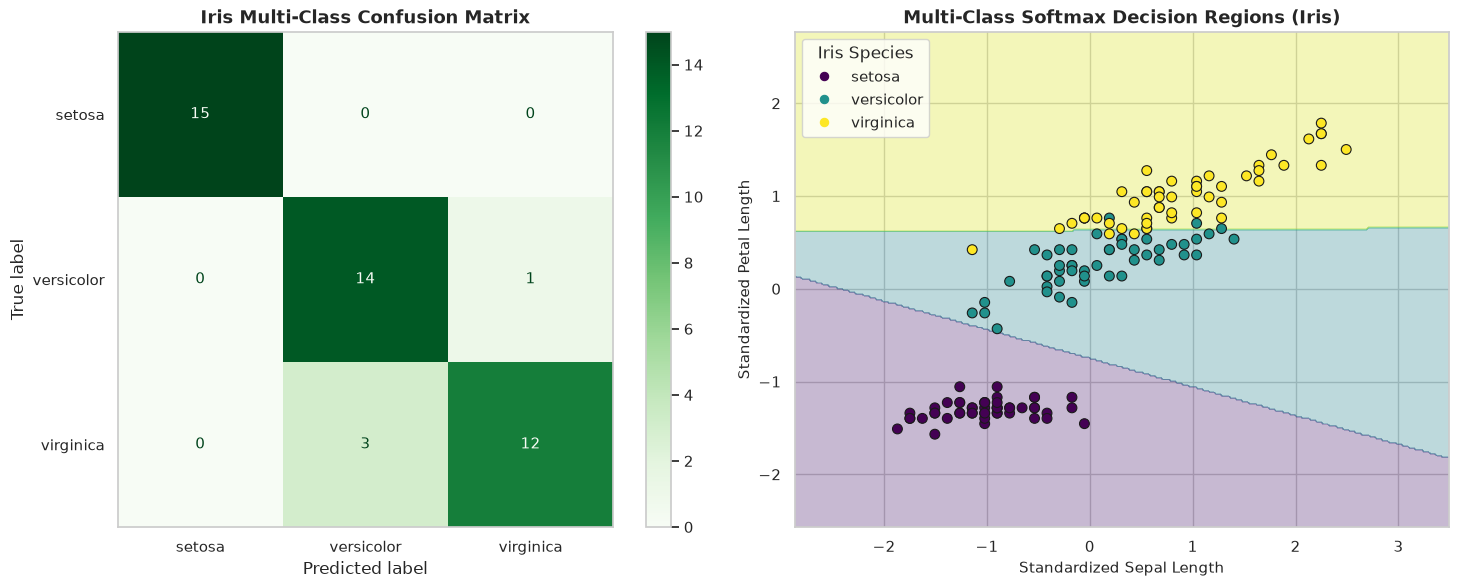

In [14]:
# Visualize Multi-Class Decision Boundaries on 2 Iris Features
X_iris_2d = iris.data[['sepal length (cm)', 'petal length (cm)']].values
y_iris_2d = iris.target.values

# Standardize 2D features
scaler_i2d = StandardScaler()
X_i2d_scaled = scaler_i2d.fit_transform(X_iris_2d)

# Train multi-class model on 2D space
multi_log_2d = LogisticRegression(solver='lbfgs', random_state=42)
multi_log_2d.fit(X_i2d_scaled, y_iris_2d)

# Meshgrid for decision regions
x_min, x_max = X_i2d_scaled[:, 0].min() - 1, X_i2d_scaled[:, 0].max() + 1
y_min, y_max = X_i2d_scaled[:, 1].min() - 1, X_i2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z_multi = multi_log_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z_multi = Z_multi.reshape(xx.shape)

# Plotting Multi-Class Decision Regions
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Multi-Class Confusion Matrix
cm_iris = confusion_matrix(y_test_i, y_pred_i)
disp_iris = ConfusionMatrixDisplay(confusion_matrix=cm_iris, display_labels=iris.target_names)
disp_iris.plot(ax=axes[0], cmap='Greens', values_format='d')
axes[0].set_title("Iris Multi-Class Confusion Matrix", fontsize=13, fontweight='bold')
axes[0].grid(False)

# Plot 2: 2D Multi-Class Decision Regions
axes[1].contourf(xx, yy, Z_multi, alpha=0.3, cmap='viridis')
scatter_iris = axes[1].scatter(X_i2d_scaled[:, 0], X_i2d_scaled[:, 1], c=y_iris_2d, 
                              cmap='viridis', edgecolors='k', linewidth=0.8, s=50)

axes[1].set_title("Multi-Class Softmax Decision Regions (Iris)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Standardized Sepal Length", fontsize=11)
axes[1].set_ylabel("Standardized Petal Length", fontsize=11)

handles, _ = scatter_iris.legend_elements()
axes[1].legend(handles, iris.target_names, loc='upper left', title="Iris Species")

plt.tight_layout()
plt.show()


# 3. Summary & Comparison Table

To conclude Module 2, let's summarize key differences and decision criteria when working with **Linear Regression** versus **Logistic Regression**.

| Feature / Aspect | Linear Regression | Logistic Regression |
| :--- | :--- | :--- |
| **Problem Type** | Regression (Continuous Target) | Classification (Discrete Categories) |
| **Target Variable $y$** | $y \in (-\infty, \infty)$ (e.g. Price, Temperature, Score) | $y \in \{0, 1\}$ or $y \in \{0, 1, \dots, K-1\}$ |
| **Model Function** | Linear combo: $\hat{y} = \mathbf{w}^T \mathbf{x} + b$ | Sigmoid/Softmax: $\hat{y} = \sigma(\mathbf{w}^T \mathbf{x} + b)$ |
| **Cost Function** | Mean Squared Error (MSE / OLS) | Binary / Categorical Cross-Entropy (Log Loss) |
| **Output Interpretation**| Expected value of target given features | Class probability $P(Y=1 \mid \mathbf{x}) \in [0, 1]$ |
| **Key Evaluation Metrics**| MAE, MSE, RMSE, $R^2$, Adjusted $R^2$ | Accuracy, Precision, Recall, F1-Score, ROC-AUC |
| **Core Diagnostic Checks**| Residual Analysis (Normality, Homoscedasticity) | Confusion Matrix, ROC Curves, Decision Boundaries |

---

### Key Takeaways
1. **Linear Regression** models continuous targets by minimizing SSE; normal equations offer exact OLS solutions, whereas Gradient Descent scales efficiently to high dimensions.
2. **Adjusted $R^2$** must be used instead of standard $R^2$ when evaluating models with multiple features to prevent false validation from non-informative predictors.
3. **Residual Analysis** is crucial for checking core OLS assumptions: linearity, homoscedasticity, independence, and normality.
4. **Logistic Regression** applies the Sigmoid (or Softmax) function to transform linear combinations into probabilities bounded in $[0, 1]$.
5. **Precision vs Recall** trade-offs depend on domain costs (e.g., minimizing False Negatives in disease diagnosis vs False Positives in spam filters).

**Congratulations on completing Module 2!** You are now ready to progress to regularized linear models (Ridge, Lasso, ElasticNet) and non-linear classification algorithms!
